NAME: SAKSHI JADHAV

ROLL NO.: EN23107043

DEPARTMENT: AIDS A

SUBJECT: VSEC ACTIVITY (ML MINI-PROJECT)

<h2> Title: Predicting Machine Efficiency in a Manufacturing Setup using Machine Learning Techniques. </h2>

<h3> Objective: Predict the Efficiency Status (Low, Medium, High) of manufacturing machines based on operational features like temperature, speed, error rate, etc. </h3>

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Dataset: https://www.kaggle.com/datasets/ziya07/intelligent-manufacturing-dataset

In [4]:
df = pd.read_csv("manufacturing.csv")

In [5]:
df

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2024-03-10 10:35:00,3,Idle,71.143556,1.861171,2.897206,11.967279,4.670305,2.823803,282.822791,0.133871,12.631304,Low
99996,2024-03-10 10:36:00,23,Idle,77.256970,0.377495,5.037060,39.687650,3.996942,6.065958,466.696532,0.775575,2.292894,Medium
99997,2024-03-10 10:37:00,10,Active,52.800333,2.629977,3.900503,26.721615,4.821022,5.090971,324.277200,0.151740,6.315872,Low
99998,2024-03-10 10:38:00,47,Active,79.967251,2.283934,7.156484,9.534678,0.481175,8.333964,65.965864,0.989501,4.802397,Low


<h3> Data Preprocessing & Cleaning: </h3>

<h4> 1.) Converting timestamp to datetime. </h4>
    
<h4> 2.) Checking data types, null values, and dataset overview. </h4>
    
<h4> 3.) Replace categorical values with numerical encoding. </h4>

In [6]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [7]:
df.dtypes

Timestamp                        datetime64[ns]
Machine_ID                                int64
Operation_Mode                           object
Temperature_C                           float64
Vibration_Hz                            float64
Power_Consumption_kW                    float64
Network_Latency_ms                      float64
Packet_Loss_%                           float64
Quality_Control_Defect_Rate_%           float64
Production_Speed_units_per_hr           float64
Predictive_Maintenance_Score            float64
Error_Rate_%                            float64
Efficiency_Status                        object
dtype: object

In [8]:
df.columns

Index(['Timestamp', 'Machine_ID', 'Operation_Mode', 'Temperature_C',
       'Vibration_Hz', 'Power_Consumption_kW', 'Network_Latency_ms',
       'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
       'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score',
       'Error_Rate_%', 'Efficiency_Status'],
      dtype='object')

In [9]:
df['Efficiency_Status'].value_counts()

Efficiency_Status
Low       77825
Medium    19189
High       2986
Name: count, dtype: int64

In [10]:
df['Operation_Mode'].value_counts()

Operation_Mode
Active         70054
Idle           20057
Maintenance     9889
Name: count, dtype: int64

In [11]:
df.isnull().sum()

Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
dtype: int64

In [12]:
df.shape

(100000, 13)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Timestamp                      100000 non-null  datetime64[ns]
 1   Machine_ID                     100000 non-null  int64         
 2   Operation_Mode                 100000 non-null  object        
 3   Temperature_C                  100000 non-null  float64       
 4   Vibration_Hz                   100000 non-null  float64       
 5   Power_Consumption_kW           100000 non-null  float64       
 6   Network_Latency_ms             100000 non-null  float64       
 7   Packet_Loss_%                  100000 non-null  float64       
 8   Quality_Control_Defect_Rate_%  100000 non-null  float64       
 9   Production_Speed_units_per_hr  100000 non-null  float64       
 10  Predictive_Maintenance_Score   100000 non-null  float64       
 11  E

<h3> Exploratory Data Analysis (EDA): </h3>

<h4> 1. Pie Chart </h4>
<h4> 2. KDE plots </h4>
<h4> 3. Histograms </h4>
<h4> 4. Distribution plots </h4>
<h4> 5. Correlation Heatmap </h4>
<h4> 6. scatterplots </h4>

<Axes: ylabel='count'>

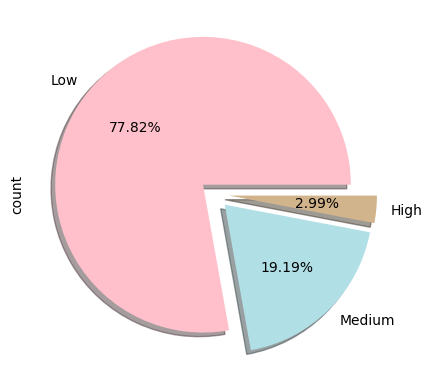

In [14]:
df['Efficiency_Status'].value_counts().plot.pie(explode=[0.1, 0.1, 0.1], autopct='%1.2f%%', shadow=True, colors=["pink", "powderblue", "tan"])

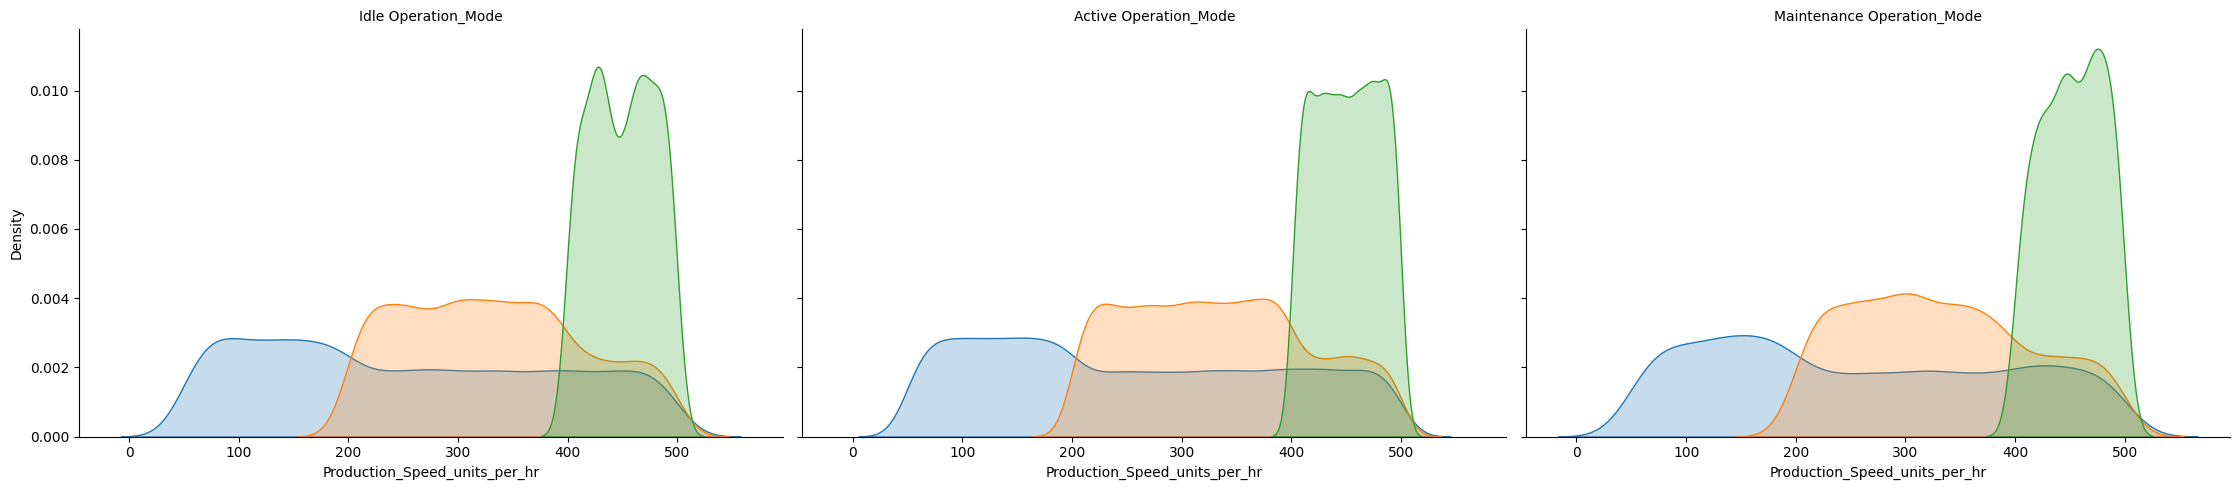

In [15]:
g = sns.FacetGrid(df, col="Operation_Mode", hue="Efficiency_Status", height=5, aspect=1.5)
g.map(sns.kdeplot, "Production_Speed_units_per_hr", fill=True)
g.set_titles("{col_name} Operation_Mode")

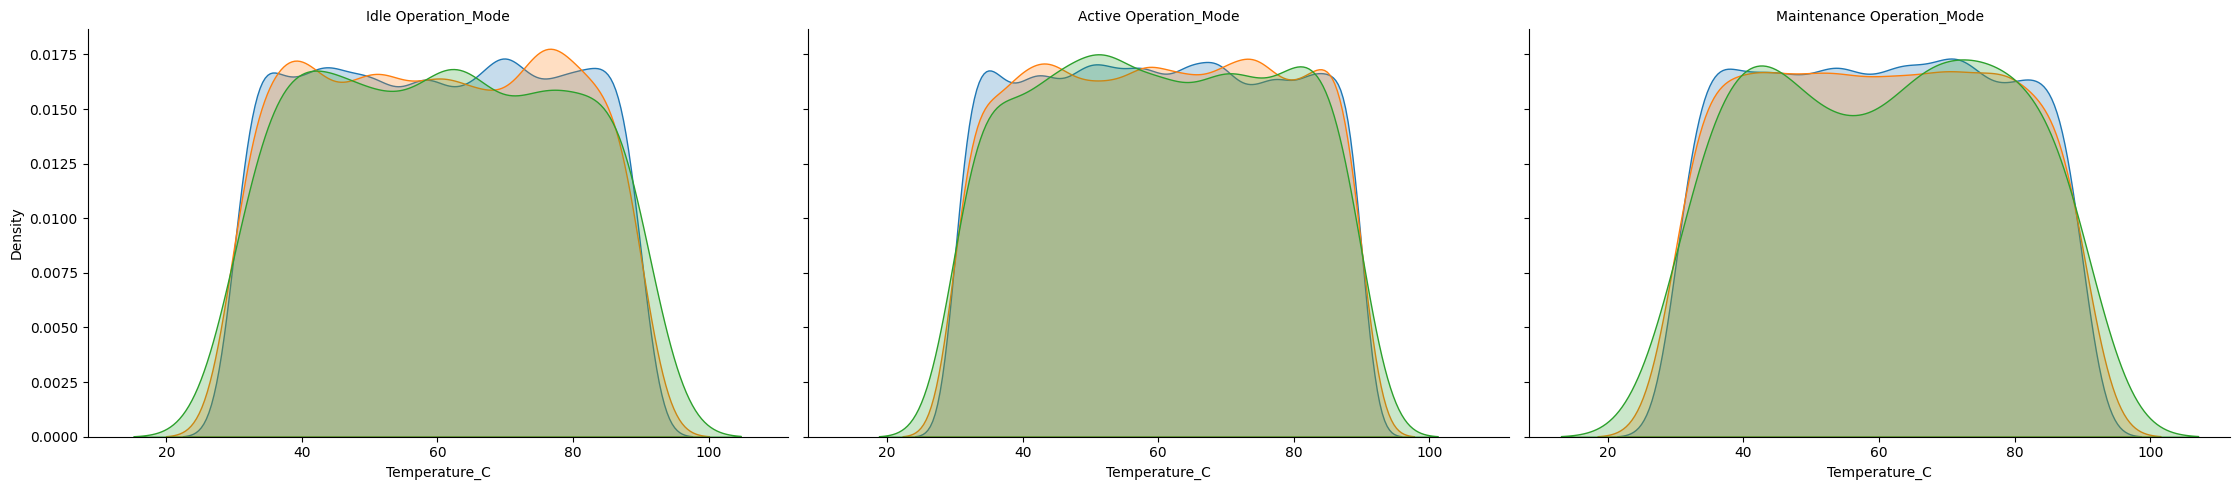

In [16]:
g = sns.FacetGrid(df, col="Operation_Mode", hue="Efficiency_Status", height=5, aspect=1.5)
g.map(sns.kdeplot, "Temperature_C", fill=True)
g.set_titles("{col_name} Operation_Mode")

<Axes: ylabel='Density'>

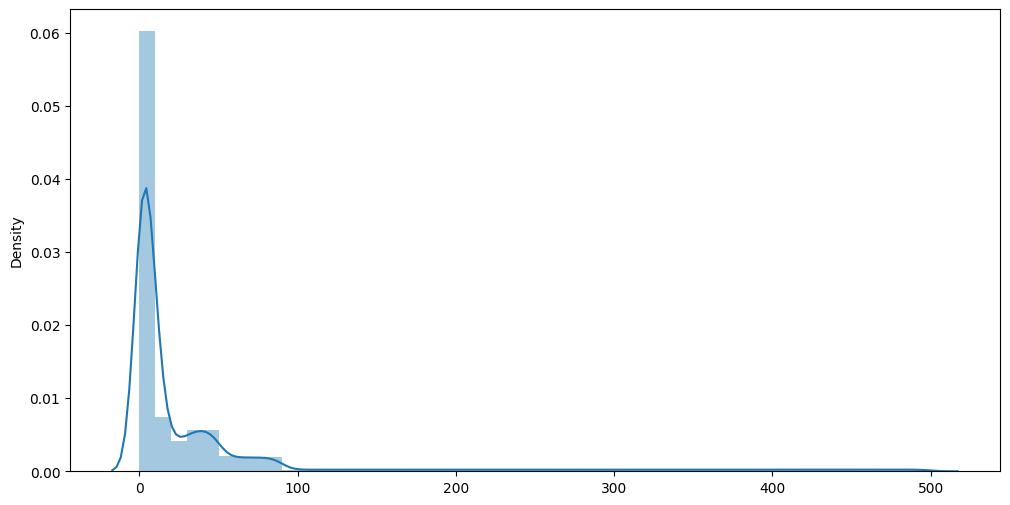

In [17]:
plt.figure(figsize=(12, 6))
sns.distplot(df.drop(columns=['Timestamp', 'Efficiency_Status', 'Operation_Mode']))

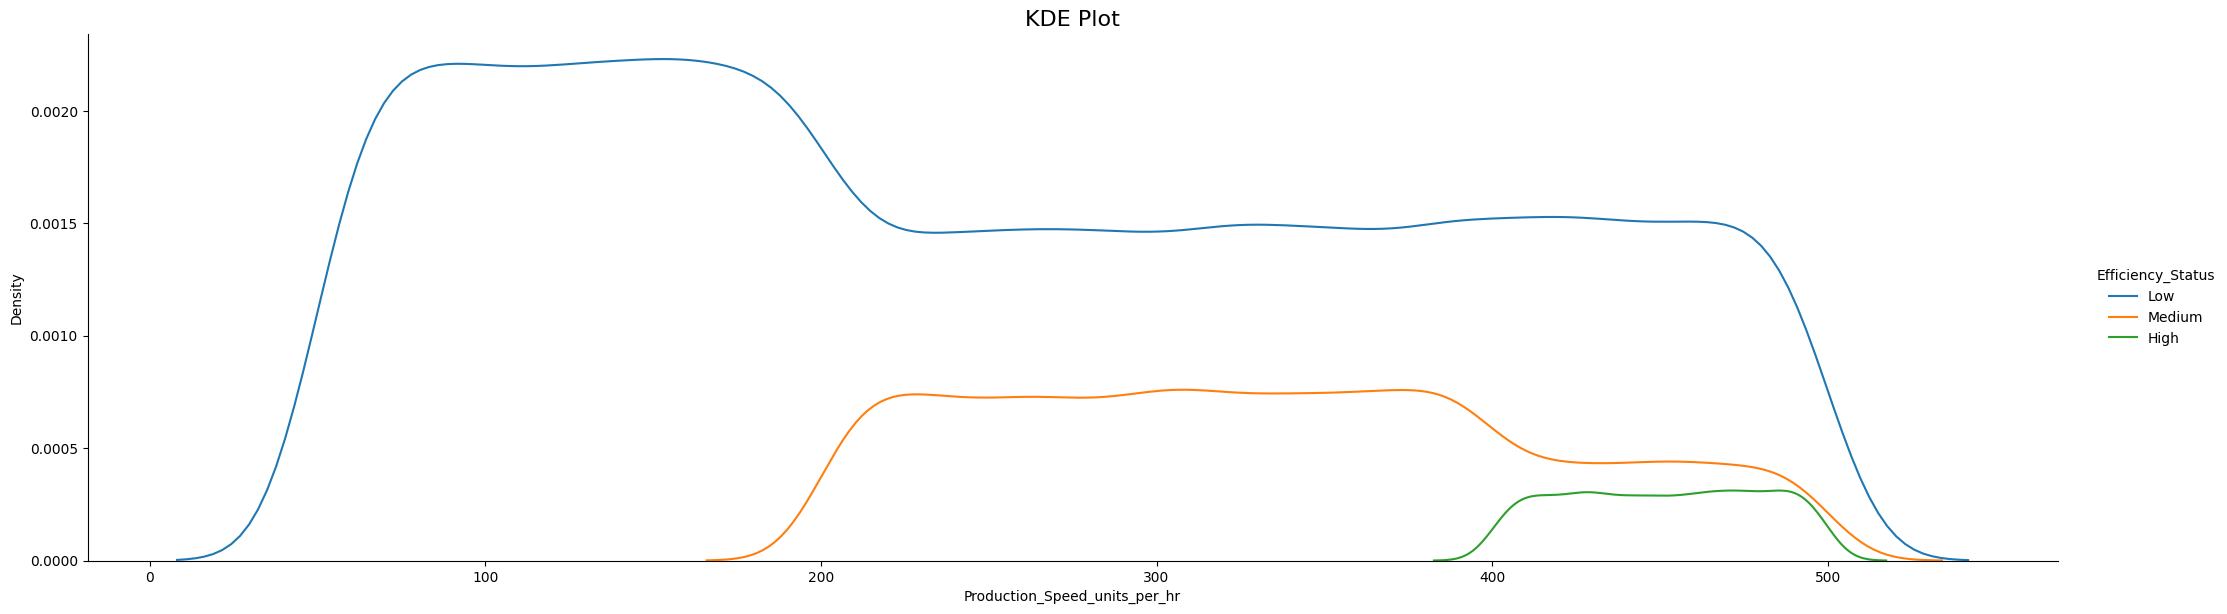

In [18]:
sns.displot(df, x="Production_Speed_units_per_hr", hue="Efficiency_Status", kind="kde", height=6, aspect=3.5, palette="tab10")
plt.title("KDE Plot", fontsize=16)
plt.show()

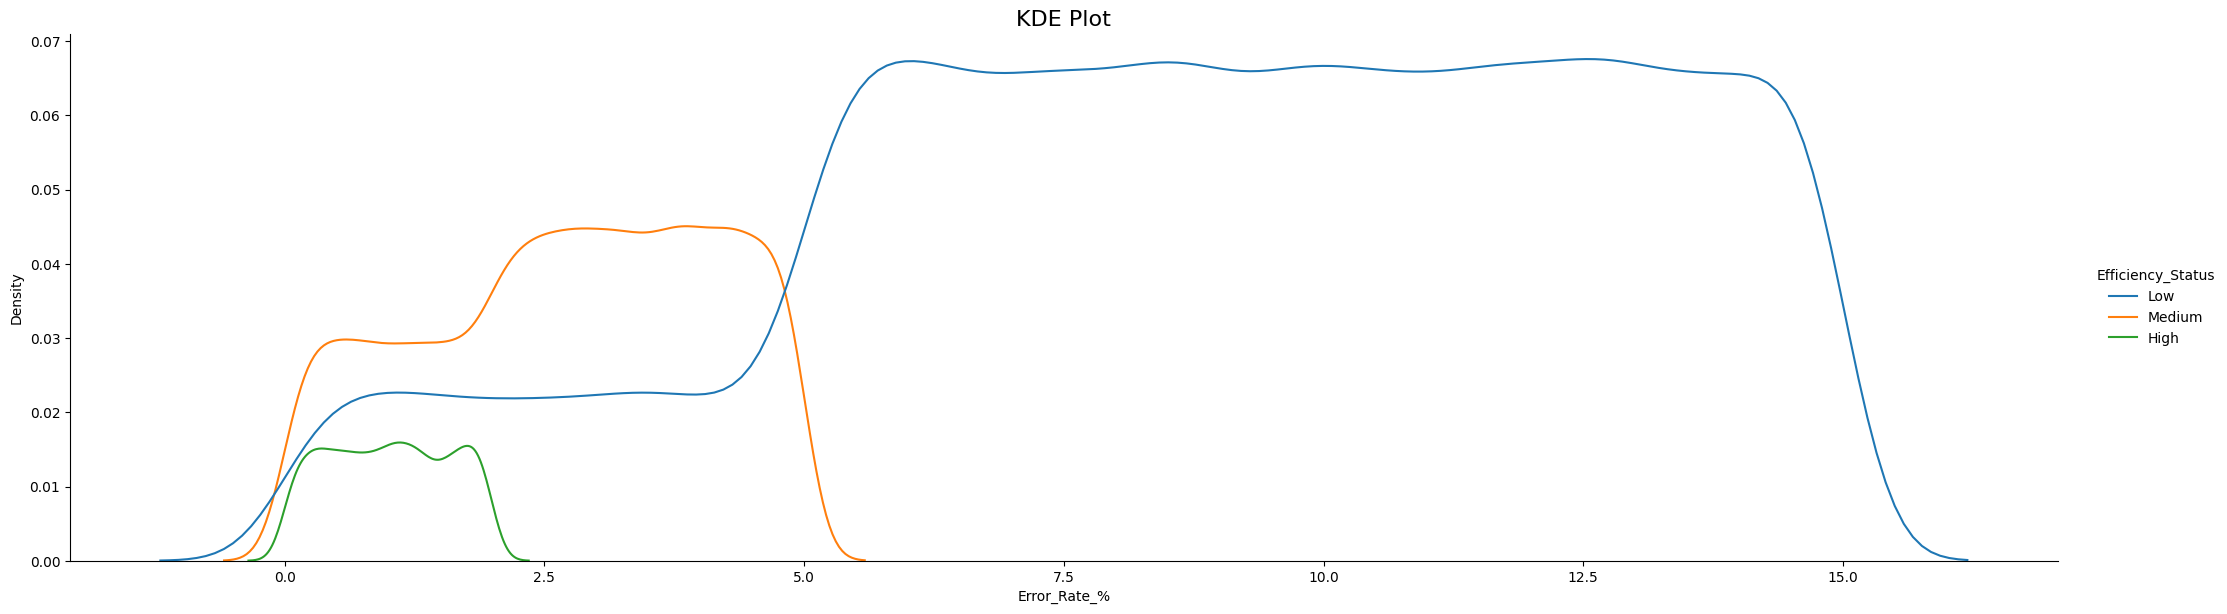

In [19]:
sns.displot(df, x="Error_Rate_%", hue="Efficiency_Status", kind="kde", height=6, aspect=3.5, palette="tab10")
plt.title("KDE Plot", fontsize=16)
plt.show()

array([[<Axes: title={'center': 'Timestamp'}>,
        <Axes: title={'center': 'Machine_ID'}>,
        <Axes: title={'center': 'Temperature_C'}>],
       [<Axes: title={'center': 'Vibration_Hz'}>,
        <Axes: title={'center': 'Power_Consumption_kW'}>,
        <Axes: title={'center': 'Network_Latency_ms'}>],
       [<Axes: title={'center': 'Packet_Loss_%'}>,
        <Axes: title={'center': 'Quality_Control_Defect_Rate_%'}>,
        <Axes: title={'center': 'Production_Speed_units_per_hr'}>],
       [<Axes: title={'center': 'Predictive_Maintenance_Score'}>,
        <Axes: title={'center': 'Error_Rate_%'}>, <Axes: >]], dtype=object)

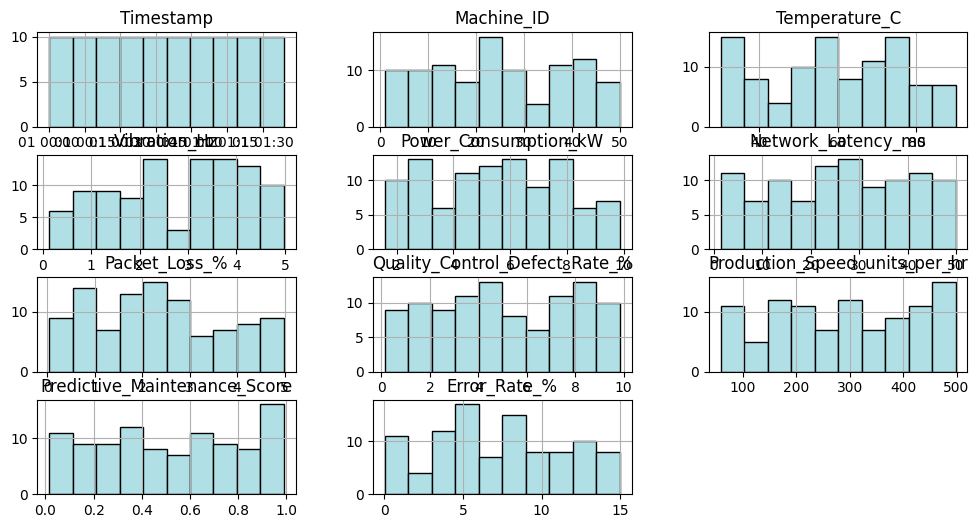

In [20]:
df.head(100).hist(figsize=(12, 6), edgecolor='black', color='powderblue')

<Axes: >

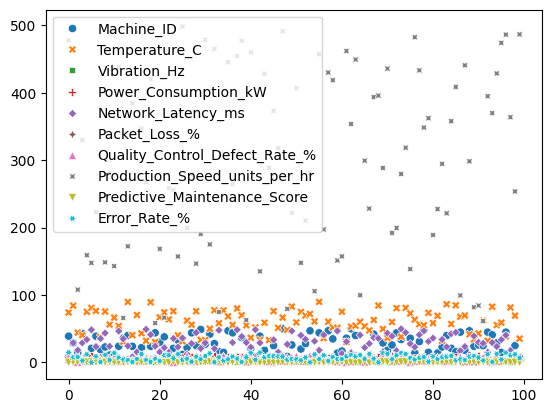

In [21]:
sns.scatterplot(df.head(100))

<Axes: xlabel='Production_Speed_units_per_hr', ylabel='Error_Rate_%'>

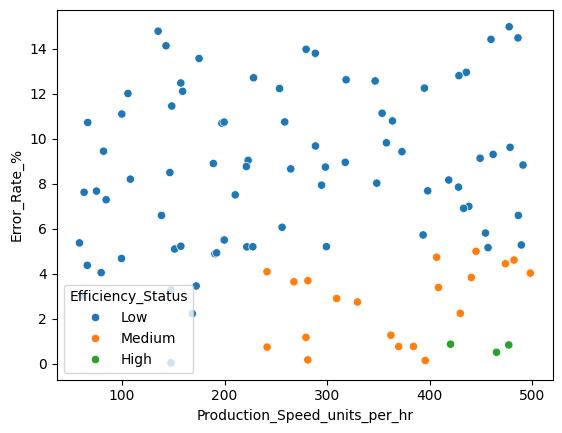

In [22]:
sns.scatterplot(x='Production_Speed_units_per_hr', y='Error_Rate_%', data=df.head(100), hue='Efficiency_Status')

Text(0.5, 1.0, 'Feature Correlation Heatmap')

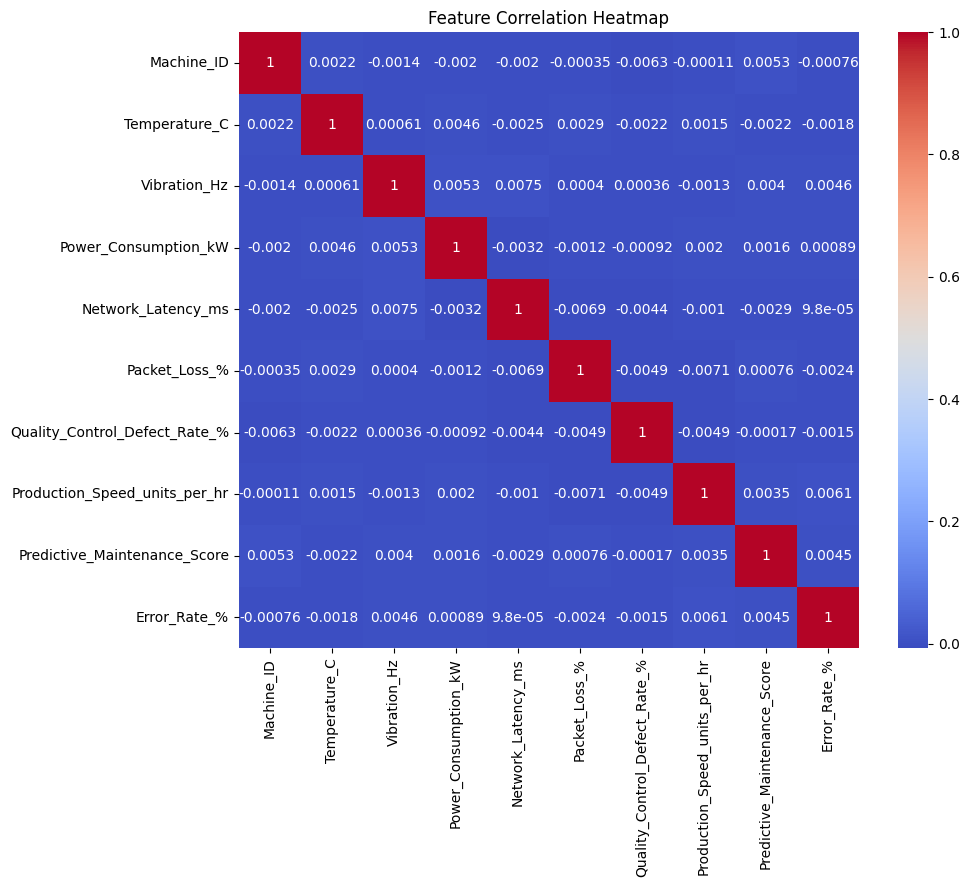

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")

In [24]:
df

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2024-03-10 10:35:00,3,Idle,71.143556,1.861171,2.897206,11.967279,4.670305,2.823803,282.822791,0.133871,12.631304,Low
99996,2024-03-10 10:36:00,23,Idle,77.256970,0.377495,5.037060,39.687650,3.996942,6.065958,466.696532,0.775575,2.292894,Medium
99997,2024-03-10 10:37:00,10,Active,52.800333,2.629977,3.900503,26.721615,4.821022,5.090971,324.277200,0.151740,6.315872,Low
99998,2024-03-10 10:38:00,47,Active,79.967251,2.283934,7.156484,9.534678,0.481175,8.333964,65.965864,0.989501,4.802397,Low


<h3> Train-Test Split and Scaling:
 </h3>

In [25]:
df.replace({'Low':0,'Medium':1,'High':2},inplace=True)
df.replace({'Active':10,'Idle':20,'Maintenance':30},inplace=True)

In [26]:
x = df.drop(columns=["Timestamp", "Efficiency_Status", "Operation_Mode", "Machine_ID"])
y = df[['Efficiency_Status']]

In [27]:
x

,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%
0,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470
1,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270
2,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391
3,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847
4,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686
...,...,...,...,...,...,...,...,...,...
99995,71.143556,1.861171,2.897206,11.967279,4.670305,2.823803,282.822791,0.133871,12.631304
99996,77.256970,0.377495,5.037060,39.687650,3.996942,6.065958,466.696532,0.775575,2.292894
99997,52.800333,2.629977,3.900503,26.721615,4.821022,5.090971,324.277200,0.151740,6.315872
99998,79.967251,2.283934,7.156484,9.534678,0.481175,8.333964,65.965864,0.989501,4.802397


In [28]:
y

,Efficiency_Status
0,0
1,0
2,0
3,1
4,0
...,...
99995,0
99996,1
99997,0
99998,0


In [29]:
df_corr = df.copy()
df_corr["Efficiency_Status"] = y
target_corr = df_corr.corr()["Efficiency_Status"].sort_values(ascending=False)

print("Correlation of each feature with target:")
print(target_corr)

Correlation of each feature with target:
Efficiency_Status                1.000000
Production_Speed_units_per_hr    0.333587
Temperature_C                    0.003824
Timestamp                        0.003685
Power_Consumption_kW             0.001191
Packet_Loss_%                    0.001020
Vibration_Hz                     0.000278
Machine_ID                      -0.000667
Network_Latency_ms              -0.001593
Predictive_Maintenance_Score    -0.003352
Operation_Mode                  -0.003670
Quality_Control_Defect_Rate_%   -0.005892
Error_Rate_%                    -0.603703
Name: Efficiency_Status, dtype: float64


In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [32]:
len(x_train)

80000

In [33]:
len(x_test)

20000

<h2> Model Building: </h2>

<h3> Model-1: Linear Regression. </h3>

In [34]:
from sklearn import linear_model

In [35]:
lr=linear_model.LinearRegression()
lr.fit(x_train_scaled, y_train)

LinearRegression()

In [36]:
linear_pred = lr.predict(x_test_scaled)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score

mae = mean_absolute_error(y_test, linear_pred)
mse = mean_squared_error(y_test, linear_pred)
sqrt_mse = np.sqrt(mse)
r2 = r2_score(y_test, linear_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Square root of MSE:", sqrt_mse)
print("R² Score:", r2)
print("Linear Regression Accuracy: ",r2*100)

Mean Absolute Error (MAE): 0.2920945435021485
Mean Squared Error (MSE): 0.13048913207311125
Square root of MSE: 0.3612327948471889
R² Score: 0.4861827429744724
Linear Regression Accuracy:  48.618274297447236


<h3> Model-2: Logistic Regression. </h3>

In [38]:
logistic = linear_model.LogisticRegression()
logistic.fit(x_train, y_train)

LogisticRegression()

In [39]:
logistic_pred = logistic.predict(x_test)
logistic_acc = accuracy_score(y_test, logistic_pred)
print("Logistic Regression Accuracy: ",logistic_acc*100)

Logistic Regression Accuracy:  89.14999999999999


              precision    recall  f1-score   support

           0       0.95      0.94      0.95     15464
           1       0.70      0.78      0.74      3911
           2       0.68      0.26      0.37       625

    accuracy                           0.89     20000
   macro avg       0.78      0.66      0.69     20000
weighted avg       0.89      0.89      0.89     20000



<Axes: >

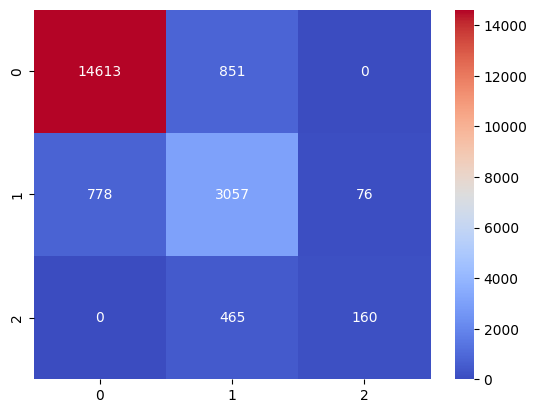

In [40]:
from sklearn.metrics import classification_report
print(classification_report(y_test, logistic_pred))
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, logistic_pred)
sns.heatmap(cm,annot=True, fmt='d',cmap='coolwarm')

<h3> Model-3: Naive Bayes. </h3>

In [41]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
gnb = GaussianNB()
gnb.fit(x_train, y_train)
gnb_pred = gnb.predict(x_test)
gnb_acc = accuracy_score(y_test, gnb_pred)

mnb = MultinomialNB()
mnb.fit(x_train, y_train)
mnb_pred = mnb.predict(x_test)
mnb_acc = accuracy_score(y_test, mnb_pred)

bnb = BernoulliNB()
bnb.fit(x_train, y_train)
bnb_pred = bnb.predict(x_test)
bnb_acc = accuracy_score(y_test, bnb_pred)

print("GNB Accuracy: ",gnb_acc*100)
print("MNB Accuracy: ",mnb_acc*100)
print("BNB Accuracy: ",bnb_acc*100)

print(classification_report(y_test, gnb_pred))
print(classification_report(y_test, mnb_pred))
print(classification_report(y_test, bnb_pred))

GNB Accuracy:  95.895
MNB Accuracy:  71.695
BNB Accuracy:  77.32
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     15464
           1       0.95      0.84      0.89      3911
           2       1.00      0.86      0.93       625

    accuracy                           0.96     20000
   macro avg       0.97      0.90      0.93     20000
weighted avg       0.96      0.96      0.96     20000

              precision    recall  f1-score   support

           0       0.92      0.76      0.83     15464
           1       0.38      0.55      0.45      3911
           2       0.26      0.70      0.38       625

    accuracy                           0.72     20000
   macro avg       0.52      0.67      0.56     20000
weighted avg       0.79      0.72      0.74     20000

              precision    recall  f1-score   support

           0       0.77      1.00      0.87     15464
           1       0.00      0.00      0.00      3911
          

<h3> Model-4: Random Forest Classifier. </h3>

In [42]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)

RandomForestClassifier()

RFC Accuracy:  100.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15464
           1       1.00      1.00      1.00      3911
           2       1.00      1.00      1.00       625

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



<Axes: >

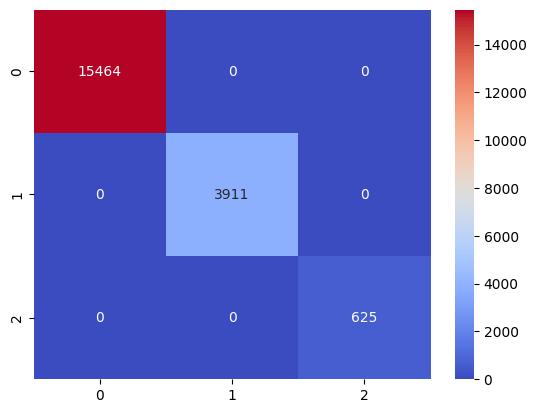

In [43]:
rfc_pred = rfc.predict(x_test)
rfc_acc = accuracy_score(y_test, rfc_pred)
print("RFC Accuracy: ",rfc_acc*100)
print(classification_report(y_test, rfc_pred))
cm = confusion_matrix(y_test, rfc_pred)
sns.heatmap(cm,annot=True, fmt='d',cmap='coolwarm')

<h4> CROSS VALIDATION FOR RFC </h4>

In [44]:
from sklearn.model_selection import cross_val_score
x_new = x.drop(columns=['Production_Speed_units_per_hr', 'Error_Rate_%'])
scores = cross_val_score(rfc, x_new, y, cv=3)
print("CV Accuracy without dominant features:", scores.mean()*100)

CV Accuracy without dominant features: 77.79899998555995


In [45]:
features = ['Error_Rate_%', 'Production_Speed_units_per_hr']
x1 = x[features]
rfc = RandomForestClassifier(random_state=42)
scores = cross_val_score(rfc, x1, y, cv=3)
print("CV with 2 features:", scores.mean()*100)

CV with 2 features: 99.9980000099995


<h3> Model-5 Decision Tree. </h3>

In [46]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

Decicion Tree Accuracy:  99.995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15464
           1       1.00      1.00      1.00      3911
           2       1.00      1.00      1.00       625

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



<Axes: >

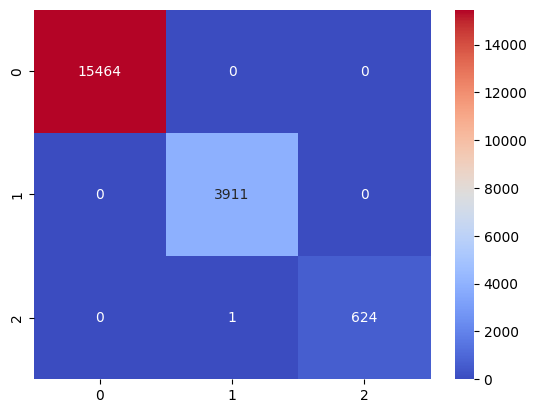

In [47]:
dt_pred = dt.predict(x_test)
dt_acc = accuracy_score(y_test, dt_pred)
print("Decicion Tree Accuracy: ",dt_acc*100)
print(classification_report(y_test, dt_pred))
cm = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm,annot=True, fmt='d',cmap='coolwarm')

<h3> Model-6: Support Vector Machine. </h3>

In [48]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(x_train_scaled, y_train)

SVC()

SVM Accuracy: 97.87
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     15464
           1       0.95      0.94      0.95      3911
           2       0.92      0.84      0.88       625

    accuracy                           0.98     20000
   macro avg       0.95      0.92      0.94     20000
weighted avg       0.98      0.98      0.98     20000



<Axes: >

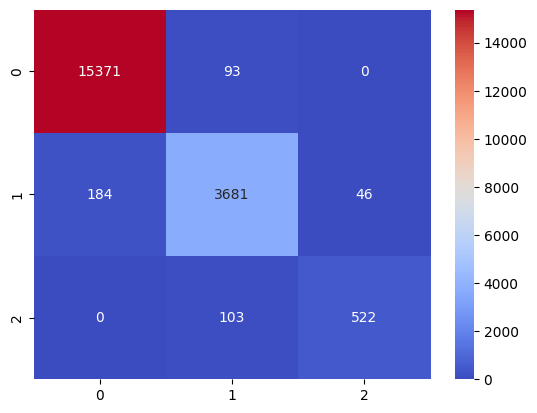

In [49]:
svc_pred = svc.predict(x_test_scaled)
svc_acc = accuracy_score(y_test, svc_pred)
print("SVM Accuracy:", svc_acc*100)
print(classification_report(y_test, svc_pred))
cm = confusion_matrix(y_test, svc_pred)
sns.heatmap(cm,annot=True, fmt='d',cmap='coolwarm')

<h3> Plotting Decision Boundary/Hyperplane: </h3>

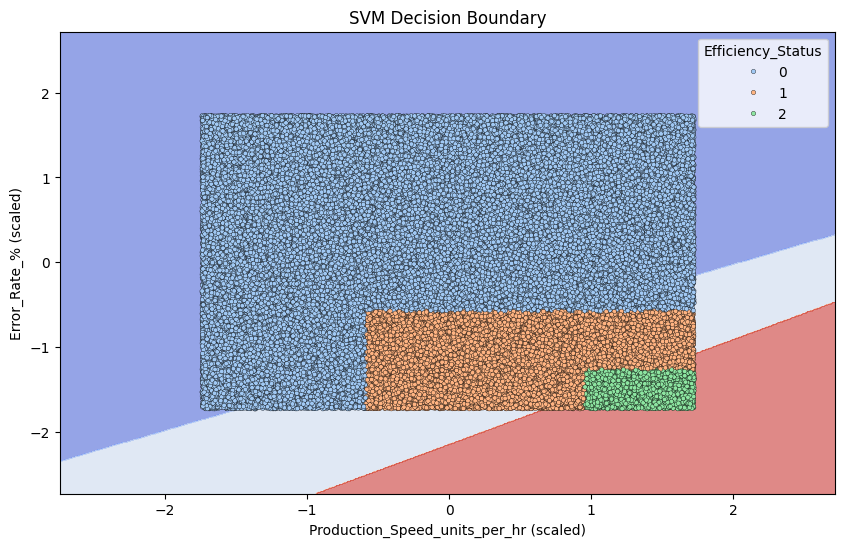

In [50]:
X = df[['Production_Speed_units_per_hr', 'Error_Rate_%']]
y = df['Efficiency_Status'] 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

svm = SVC(kernel='linear') 
svm.fit(X_scaled, y)

h = 0.01
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),np.arange(y_min, y_max, h))
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.6)
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y, palette='pastel', s=10, edgecolor='k')
plt.title("SVM Decision Boundary")
plt.xlabel('Production_Speed_units_per_hr (scaled)')
plt.ylabel('Error_Rate_% (scaled)')
plt.show()

<h3> Model-7 k-nearest neighbors </h3>

In [51]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)  
knn.fit(x_train_scaled, y_train)

KNeighborsClassifier()

KNN Accuracy: 92.53
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     15464
           1       0.81      0.81      0.81      3911
           2       0.74      0.39      0.51       625

    accuracy                           0.93     20000
   macro avg       0.84      0.73      0.76     20000
weighted avg       0.92      0.93      0.92     20000



<Axes: >

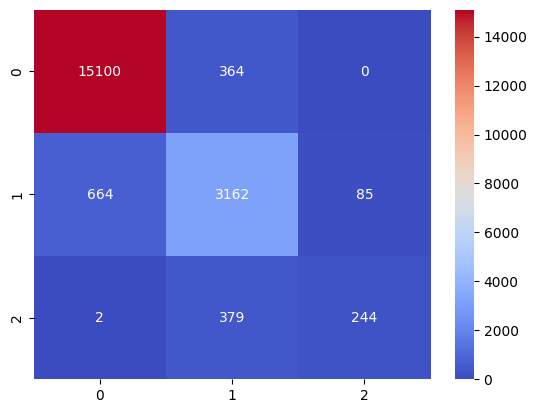

In [52]:
knn_pred = knn.predict(x_test_scaled)
knn_acc = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_acc*100)
print(classification_report(y_test, knn_pred))
cm = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm,annot=True, fmt='d',cmap='coolwarm')

<h2> Unsupervised- Clustering. </h2>

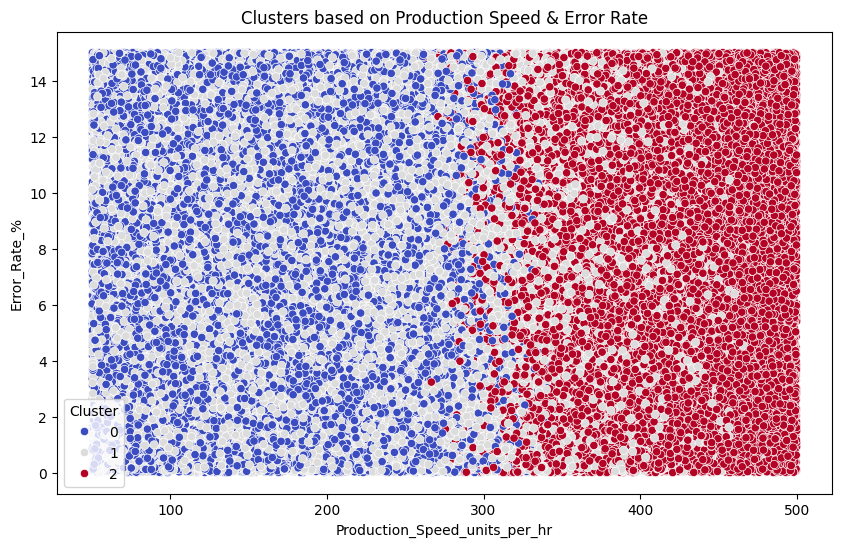

In [55]:
from sklearn.cluster import KMeans

features = df.drop(columns=['Timestamp', 'Efficiency_Status', 'Operation_Mode'])
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Production_Speed_units_per_hr', y='Error_Rate_%', hue='Cluster', data=df, palette='coolwarm')
plt.title("Clusters based on Production Speed & Error Rate")
plt.show()

<h3> MODEL EVALUATION: </h3>

In [59]:
model_accuracies = {
    "Linear Regression (R²)": r2 * 100,
    "Logistic Regression": logistic_acc * 100,
    "GaussianNB": gnb_acc * 100,
    "MultinomialNB": mnb_acc * 100,
    "BernoulliNB": bnb_acc * 100,
    "Random Forest": rfc_acc * 100,
    "Decision Tree": dt_acc * 100,
    "SVM": svc_acc * 100
}

summary_df = pd.DataFrame(model_scores.items(), columns=["Model", "Accuracy (%)"])
summary_df.sort_values("Accuracy (%)", ascending=False).reset_index(drop=True)

,Model,Accuracy (%)
0,Random Forest,100.000000
1,Decision Tree,99.995000
2,SVM,97.870000
3,GaussianNB,95.895000
4,Logistic Regression,89.150000
5,BernoulliNB,77.320000
6,MultinomialNB,71.695000
7,Linear Regression (R²),48.618274


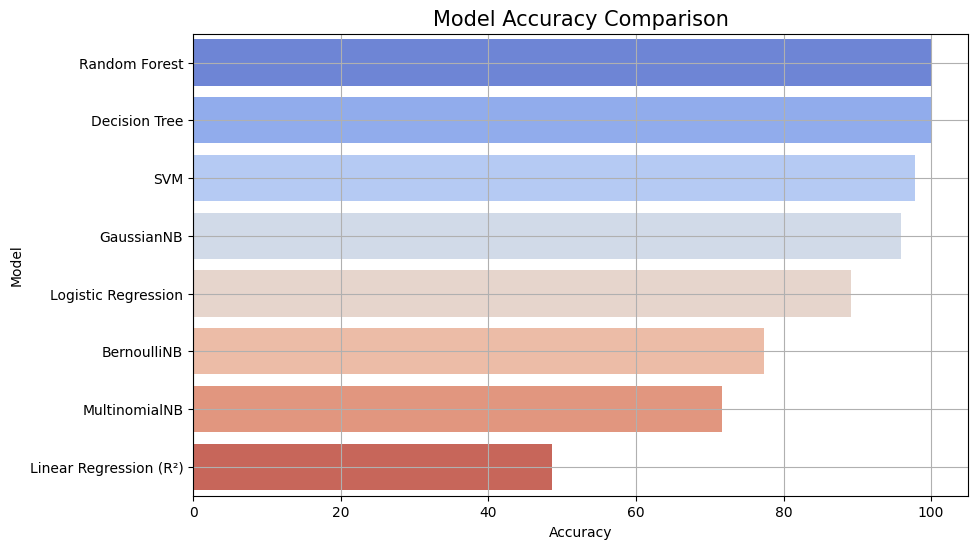

In [60]:
accuracy_df = pd.DataFrame(model_accuracies.items(), columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=accuracy_df, x="Accuracy", y="Model", palette="coolwarm")
plt.title("Model Accuracy Comparison", fontsize=15)
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.grid()
plt.show()


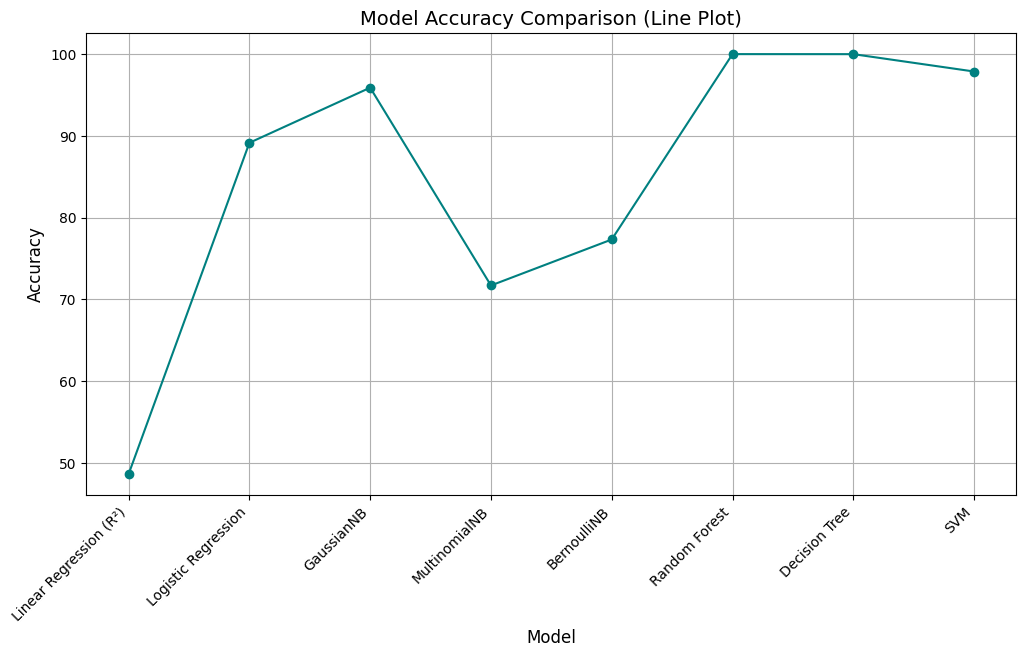

In [61]:
models = list(model_accuracies.keys())
accuracies = list(model_accuracies.values())

plt.figure(figsize=(12, 6))
plt.plot(models, accuracies, marker='o', linestyle='-', color='teal')
plt.title("Model Accuracy Comparison (Line Plot)", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.show()

## Project Summary: Machine Efficiency Classification

### Objective:
The goal of this project is to build a predictive model that classifies the **Efficiency Status** of industrial machines (`Low`, `Medium`, `High`) using a rich set of sensor and operational features. This falls under a **multiclass classification** problem.

---

### Dataset Overview:
- The dataset contains **machine-level metrics**, including:
  - `Temperature_C`, `Vibration_Hz`, `Power_Consumption_kW`
  - `Network_Latency_ms`, `Packet_Loss_%`, `Error_Rate_%`, etc.
  - Target variable: `Efficiency_Status` (categorical)
- Total samples: _(100000)_
- Features include both **numeric and categorical** values, preprocessed appropriately.

---

### Exploratory Data Analysis (EDA):
- Distribution plots, pairplots, and heatmaps were used to understand feature relationships.
- Correlation matrix highlighted strong relationships between:
  - `Power_Consumption_kW` and `Production_Speed_units_per_hr`
  - `Error_Rate_%` and `Quality_Control_Defect_Rate_%`
- Scatter plots revealed patterns in how efficiency levels relate to key metrics.

---

### Models Applied:
- Linear Regression (optional implemented just to check the accuracy)
- Logistic Regression
- Naive Bayes
- Support Vector Machine (SVC)
- Decision Tree Classifier
- Random Forest Classifier
- K-Nearest Neighbors (KNN)

 All models were evaluated using **accuracy** and confusion matrices.

A separate section explored **SVC decision boundaries**, visualizing class separation in 2D space using selected features.

---

###  Clustering (Unsupervised Learning):
Although the task is supervised, **K-Means clustering** was performed to:
- Discover hidden groupings within the data
- Compare cluster assignments to true `Efficiency_Status` labels
- Visualize clusters using PCA (or 2D feature plots)

This provided **additional insight** into the natural structure of the data.

---

###  (Optional) Regression Extension:
An additional experiment involved treating `Efficiency_Status` as a **numeric target** (`Low`=0, `Medium`=1, `High`=2), applying regression models to predict efficiency levels as a continuous outcome. This showcases flexibility in framing the problem.

---

### Visualizations Included:
- Heatmaps & pairplots
- Scatter plots with hue, size, and custom palettes
- Decision boundary plot (SVC)
- Clustering plot (KMeans)
- Distribution plots

---

### Conclusion:
- The classification models achieved solid performance, with **Random Forest and SVC** giving the highest accuracy.
- Visual insights and clustering validated the predictive structure of the data.
- The project effectively demonstrates a full data science workflow — from preprocessing and EDA, to modeling, evaluation, and interpretability — using both supervised and unsupervised techniques.

---

In [62]:
df1=df.copy()
df1['SMA'] = df['Error_Rate_%'].rolling(window=20).mean()
df1['CMA'] = df['Error_Rate_%'].expanding().mean()
df1['EMA'] = df['Error_Rate_%'].ewm(span=10).mean()
df1.head(10)

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status,Cluster,SMA,CMA,EMA
0,2024-01-01 00:00:00,39,20,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,0,2,NaN,14.965470,14.965470
1,2024-01-01 00:01:00,29,10,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,0,2,NaN,11.321870,10.957510
2,2024-01-01 00:02:00,15,10,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,0,0,NaN,10.280710,9.848363
3,2024-01-01 00:03:00,43,10,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,1,2,NaN,8.395745,7.506753
4,2024-01-01 00:04:00,8,20,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,0,0,NaN,9.136733,8.825546
5,2024-01-01 00:05:00,21,10,80.959793,1.385607,9.868068,48.399315,0.575012,4.720913,147.687703,0.897386,0.040716,0,0,NaN,7.620730,6.543822
6,2024-01-01 00:06:00,39,10,76.434701,4.815294,2.616830,23.517123,2.089320,4.894678,222.974691,0.220540,9.032313,0,0,NaN,7.822385,7.143449
7,2024-01-01 00:07:00,19,10,37.670279,4.436610,7.659486,35.451097,3.258246,4.235901,241.456735,0.911839,0.738357,1,0,NaN,6.936881,5.686259
8,2024-01-01 00:08:00,23,10,75.546612,3.128203,2.679066,43.648262,2.884069,7.551568,148.458144,0.500589,11.446013,0,1,NaN,7.437896,6.939380
9,2024-01-01 00:09:00,11,10,56.324709,0.647725,3.401835,23.985566,0.563528,6.335666,281.258013,0.805492,3.687912,1,1,NaN,7.062898,6.256389
